# Walmart Forecasting - Exploratory Data Analysis

This notebook explores the cleaned Walmart sales data and focuses on the patterns that matter most for forecasting: trend, seasonality, store-level differences, holiday effects, and relationships with external variables.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_PATH = Path("../data/Walmart_cleaned.csv")

In [2]:
# Load cleaned data
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter,Is_Weekend
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1,0
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1,0
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1,0
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1,0
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1,0


In [3]:
# Basic overview
print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Number of stores: {df['Store'].nunique()}")
display(df.info())
display(df.describe(include="all").T)

Shape: (6435, 13)
Date range: 2010-02-05 to 2012-10-26
Number of stores: 45
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int64         
 9   Month         6435 non-null   int64         
 10  Week          6435 non-null   int64         
 11  Quarter       6435 non-null   int64         
 12  Is_Weekend    6435 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(7)
memory usage: 653.7

None

,count,mean,min,25%,50%,75%,max,std
Store,6435.0,23.0,1.0,12.0,23.0,34.0,45.0,12.988182
Date,6435,2011-06-17 00:00:00,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,6435.0,1046964.877562,209986.25,553350.105,960746.04,1420158.66,3818686.45,564366.622054
Holiday_Flag,6435.0,0.06993,0.0,0.0,0.0,0.0,1.0,0.255049
Temperature,6435.0,60.663782,-2.06,47.46,62.67,74.94,100.14,18.444933
Fuel_Price,6435.0,3.358607,2.472,2.933,3.445,3.735,4.468,0.45902
CPI,6435.0,171.578394,126.064,131.735,182.616521,212.743293,227.232807,39.356712
Unemployment,6435.0,7.999151,3.879,6.891,7.874,8.622,14.313,1.875885
Year,6435.0,2010.965035,2010.0,2010.0,2011.0,2012.0,2012.0,0.797019
Month,6435.0,6.447552,1.0,4.0,6.0,9.0,12.0,3.238308


## Missing Values and Duplicates

In [4]:
quality_checks = pd.Series(
    {
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "duplicate_store_date_pairs": int(df.duplicated(subset=["Store", "Date"]).sum())
    },
    name="count"
)

quality_checks

missing_values                0
duplicate_rows                0
duplicate_store_date_pairs    0
Name: count, dtype: int64

## Univariate Analysis

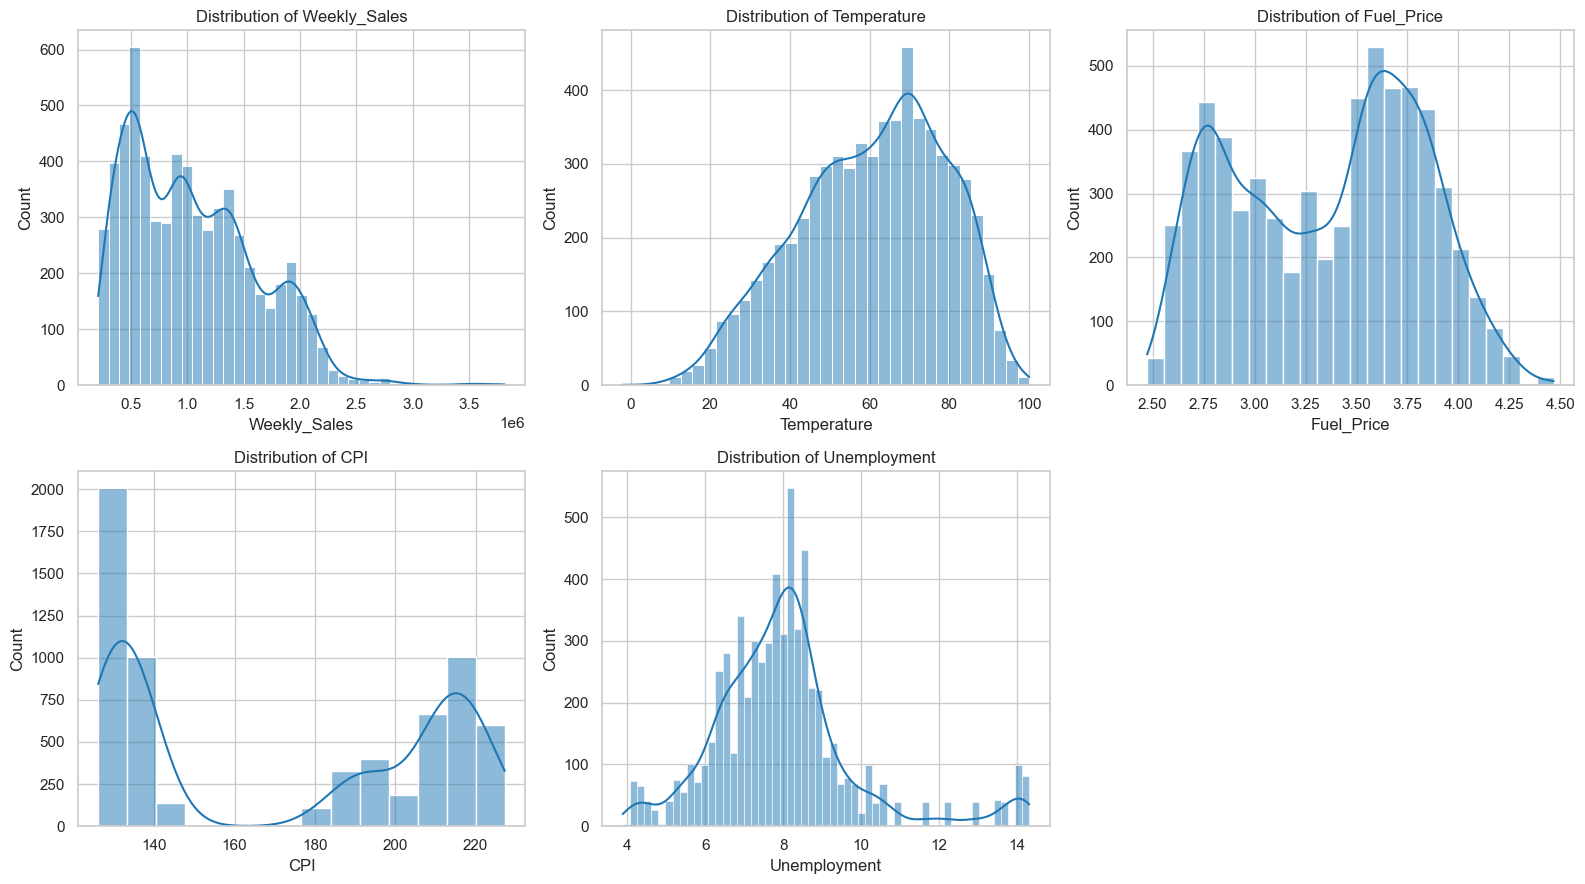

In [5]:
numeric_cols = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#1f77b4")
    axes[i].set_title(f"Distribution of {col}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

**What this cell outputs:**

This cell creates histogram plots with KDE curves for `Weekly_Sales`, `Temperature`, `Fuel_Price`, `CPI`, and `Unemployment`. It helps us see the overall shape, spread, skewness, and concentration of each numeric variable.

**Takeaway:**

`Weekly_Sales` is spread widely and is slightly right-skewed, which means some store-weeks generate much higher sales than usual. The other variables look much more stable, so sales variability is much larger than the variability in the external features.

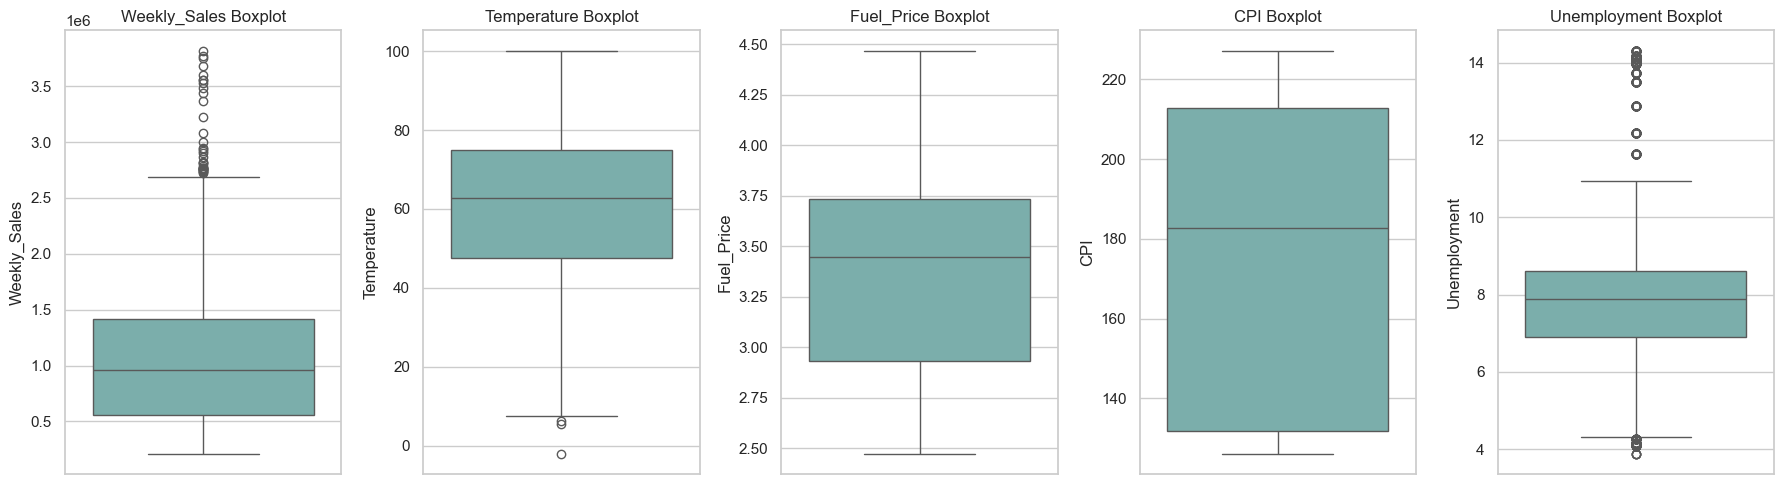

In [6]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#72b7b2")
    ax.set_title(f"{col} Boxplot")

plt.tight_layout()
plt.show()

**What this cell outputs:**

This cell shows boxplots for the same numeric columns. Boxplots highlight the median, interquartile range, and possible outliers in each variable.

**Takeaway:**

`Weekly_Sales` clearly contains many high-value observations, which is common in retail data and especially important in forecasting because holiday peaks and top-performing stores can behave very differently from the average week. These values should be studied, not removed blindly.

## Sales Trend Over Time

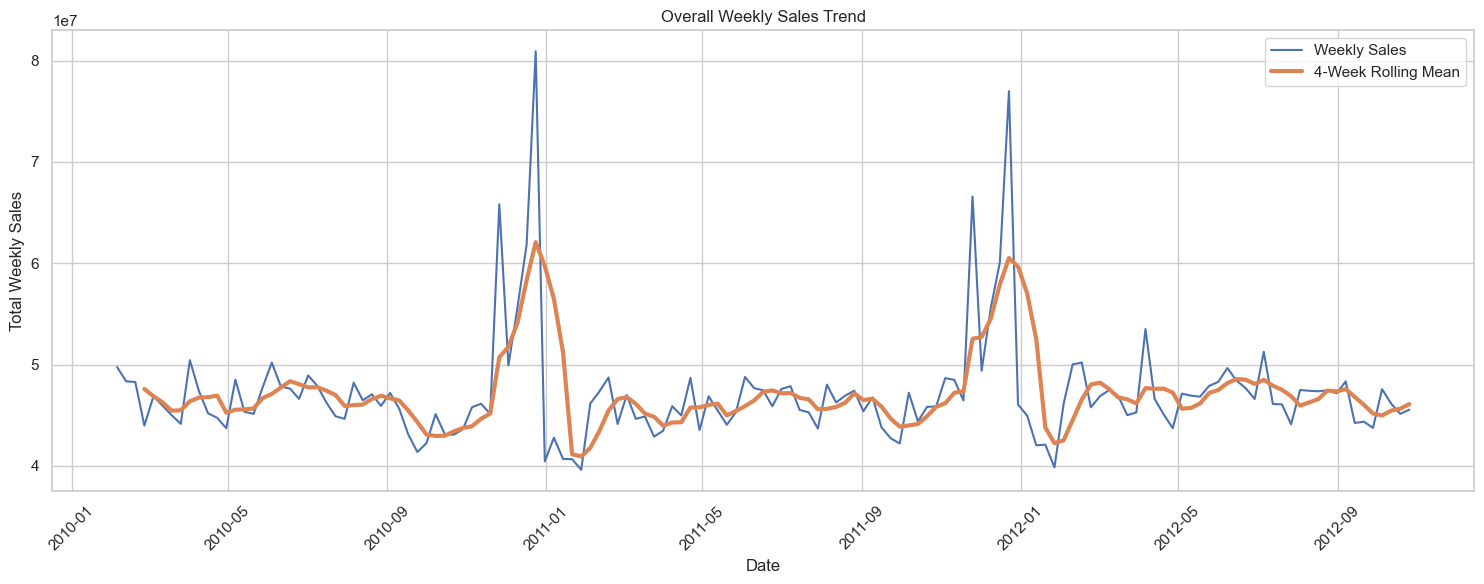

In [7]:
weekly_trend = df.groupby("Date", as_index=False)["Weekly_Sales"].sum()
weekly_trend["Rolling_4_Week"] = weekly_trend["Weekly_Sales"].rolling(4).mean()

plt.figure(figsize=(15, 6))
sns.lineplot(data=weekly_trend, x="Date", y="Weekly_Sales", label="Weekly Sales")
sns.lineplot(data=weekly_trend, x="Date", y="Rolling_4_Week", label="4-Week Rolling Mean", linewidth=3)
plt.title("Overall Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**What this cell outputs:**

This cell plots the total weekly sales across all stores over time, along with a 4-week rolling average. The rolling line smooths out short-term noise so the broader direction becomes easier to read.

**Takeaway:**

Sales show clear ups and downs over time, with noticeable peaks that likely align with holiday or seasonal demand. The rolling mean makes it clear that this is time-dependent data, so forecasting must preserve time order.

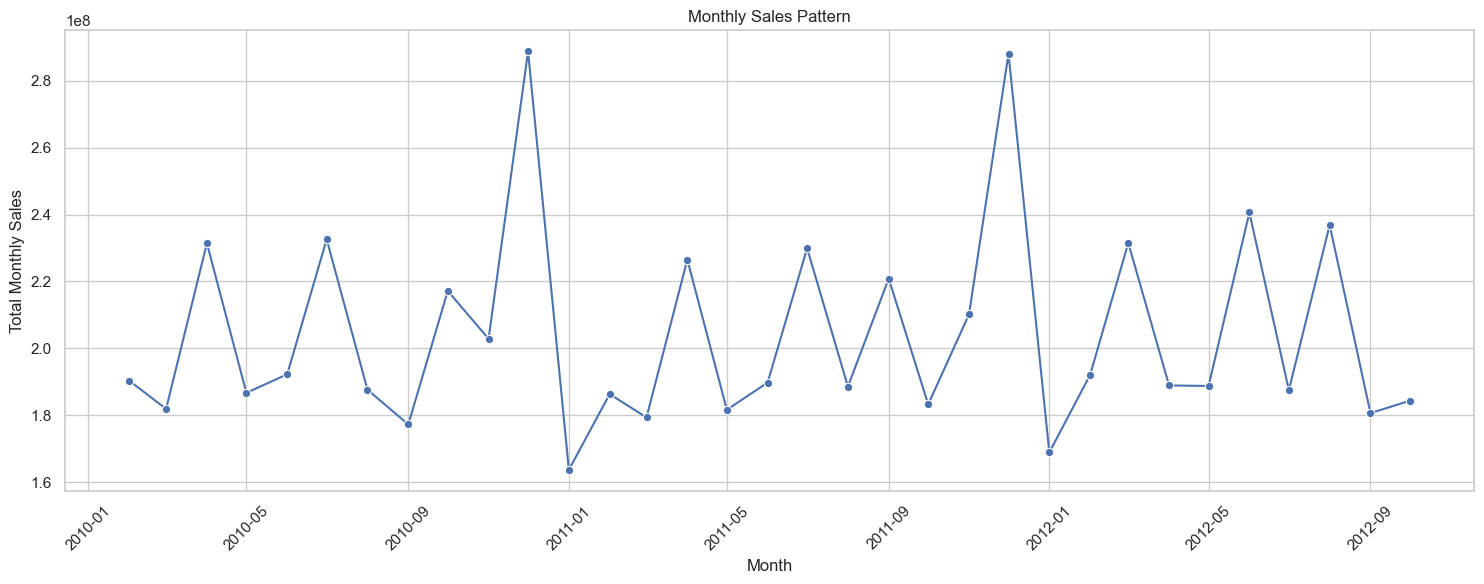

In [8]:
monthly_sales = df.groupby(["Year", "Month"], as_index=False)["Weekly_Sales"].sum()
monthly_sales["Year_Month"] = pd.to_datetime(monthly_sales[["Year", "Month"]].assign(DAY=1))

plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_sales, x="Year_Month", y="Weekly_Sales", marker="o")
plt.title("Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Total Monthly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**What this cell outputs:**

This cell aggregates weekly sales into monthly totals and plots them over time. It helps us see medium-term movement more clearly than the week-level chart.

**Takeaway:**

The monthly pattern makes seasonality easier to spot. Stronger sales toward certain parts of the year suggest that month- or quarter-based features will likely help the forecasting model.

## Store-Level Analysis

,mean,sum,std
Store,,,
20,2107676.87,3.013978e+08,275900.56
4,2094712.96,2.995440e+08,266201.44
14,2020978.40,2.889999e+08,317569.95
13,2003620.31,2.865177e+08,265507.00
2,1925751.34,2.753824e+08,237683.69
10,1899424.57,2.716177e+08,302262.06
27,1775216.20,2.538559e+08,239930.14
6,1564728.19,2.237561e+08,212525.86
1,1555264.40,2.224028e+08,155980.77


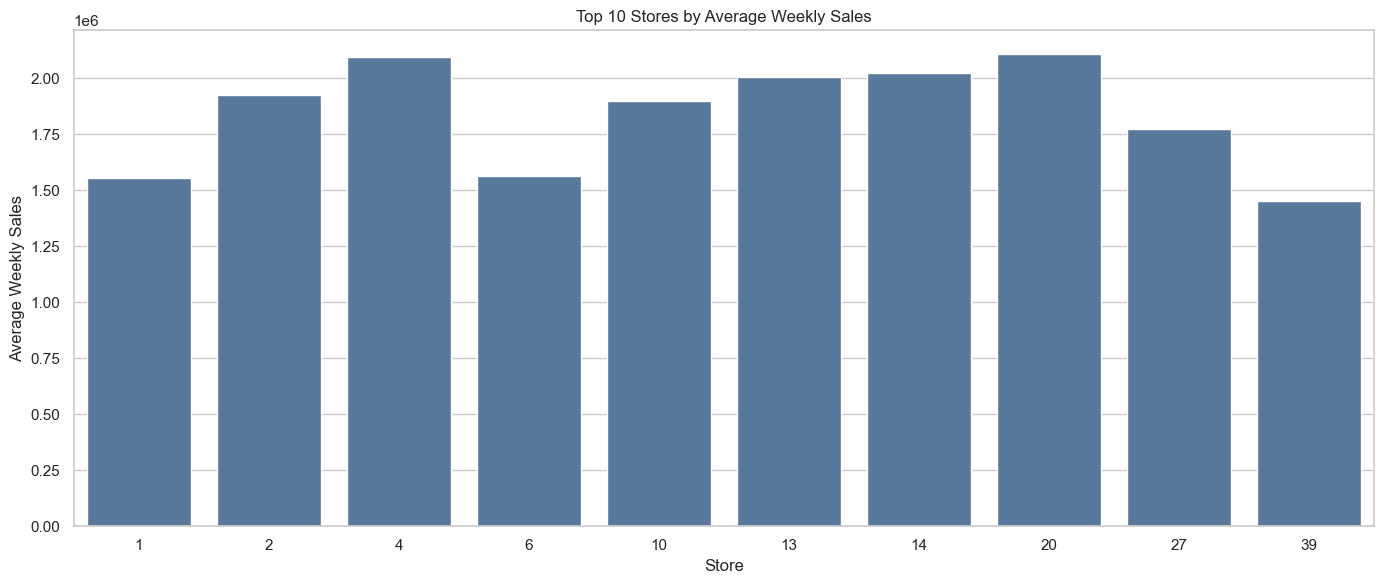

In [9]:
store_performance = df.groupby("Store")["Weekly_Sales"].agg(["mean", "sum", "std"]).sort_values("mean", ascending=False)
display(store_performance.head(10).round(2))

top_10_stores = store_performance.head(10).reset_index()
plt.figure(figsize=(14, 6))
sns.barplot(data=top_10_stores, x="Store", y="mean", color="#4c78a8")
plt.title("Top 10 Stores by Average Weekly Sales")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.tight_layout()
plt.show()

**What this cell outputs:**

This cell calculates store-wise mean, total, and standard deviation of weekly sales, then displays the top 10 stores by average weekly sales in both a table and a bar chart.

**Takeaway:**

Store performance is not uniform. Some stores consistently generate much higher sales, which tells us store identity is a very important forecasting feature and we should not treat all stores as if they behave the same way.

Top 5 Store IDs: [20, 4, 14, 13, 2]


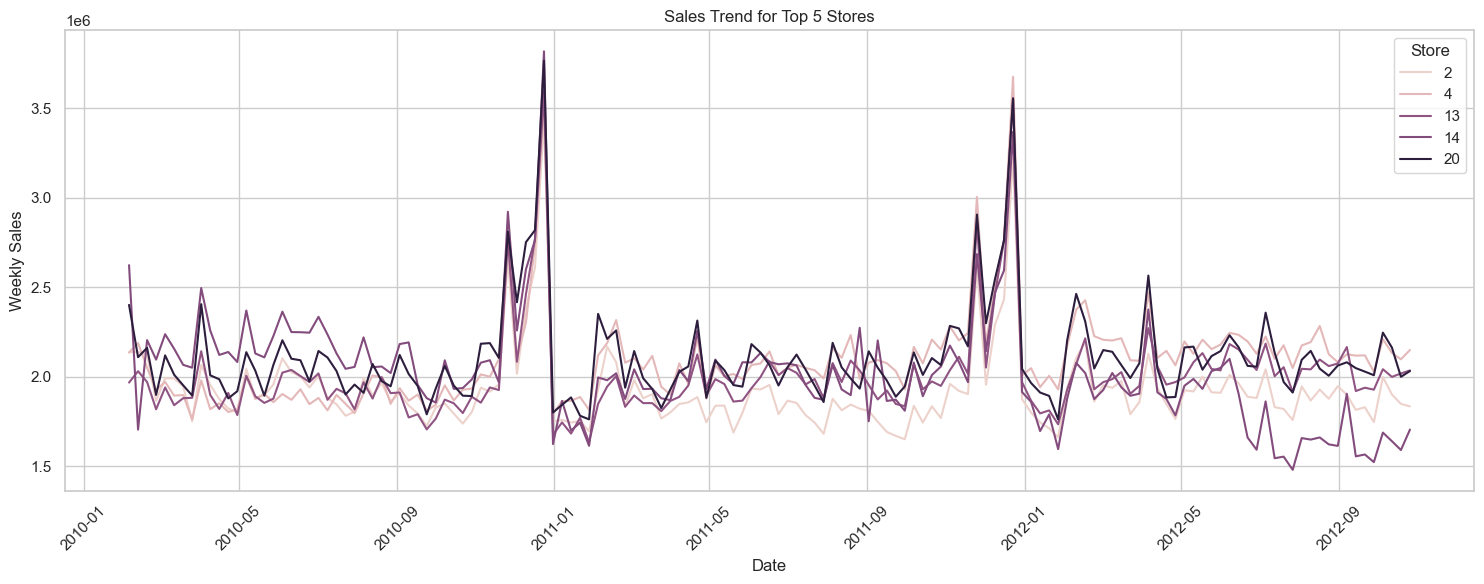

In [16]:
top_store_ids = store_performance.head(5).index.tolist()
print(f"Top 5 Store IDs: {top_store_ids}")
top_store_trend = df[df["Store"].isin(top_store_ids)]

plt.figure(figsize=(15, 6))
sns.lineplot(data=top_store_trend, x="Date", y="Weekly_Sales", hue="Store")
plt.title("Sales Trend for Top 5 Stores")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**What this cell outputs:**

This cell plots the weekly sales trend for the top 5 stores by average sales. It compares their movement over time on the same chart.

**Takeaway:**

Even the best stores do not move exactly the same way. They may share broad seasonal peaks, but each store still has its own scale and volatility, which supports using store-level or panel-style forecasting rather than one single global pattern only.

## Holiday Effect

,mean,median,sum,count
Holiday_Flag,,,,
0,1041256.38,956211.20,6.231919e+09,5985
1,1122887.89,1018538.04,5.052996e+08,450


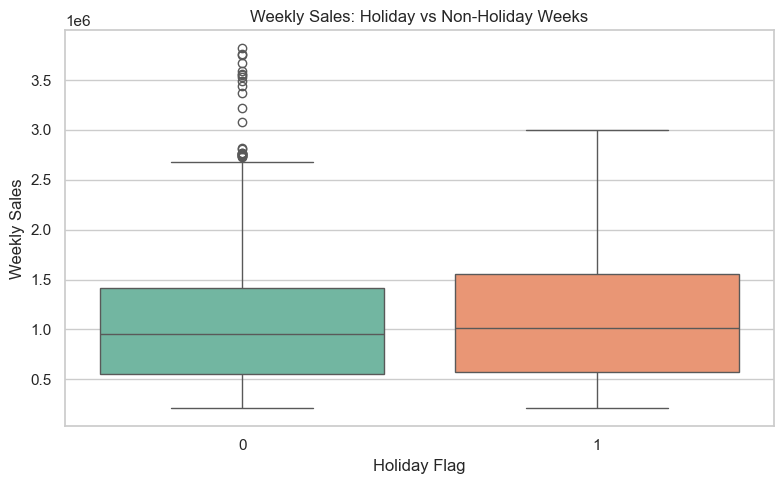

In [11]:
holiday_summary = df.groupby("Holiday_Flag")["Weekly_Sales"].agg(["mean", "median", "sum", "count"]).round(2)
display(holiday_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Holiday_Flag", y="Weekly_Sales", palette="Set2")
plt.title("Weekly Sales: Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday Flag")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

**What this cell outputs:**

This cell summarizes sales for holiday and non-holiday weeks and then compares the distributions using a boxplot.

**Takeaway:**

Holiday weeks generally show stronger sales behavior and more extreme values. That means `Holiday_Flag` is an important business feature and should definitely be included in the forecasting model.

## Seasonality Checks

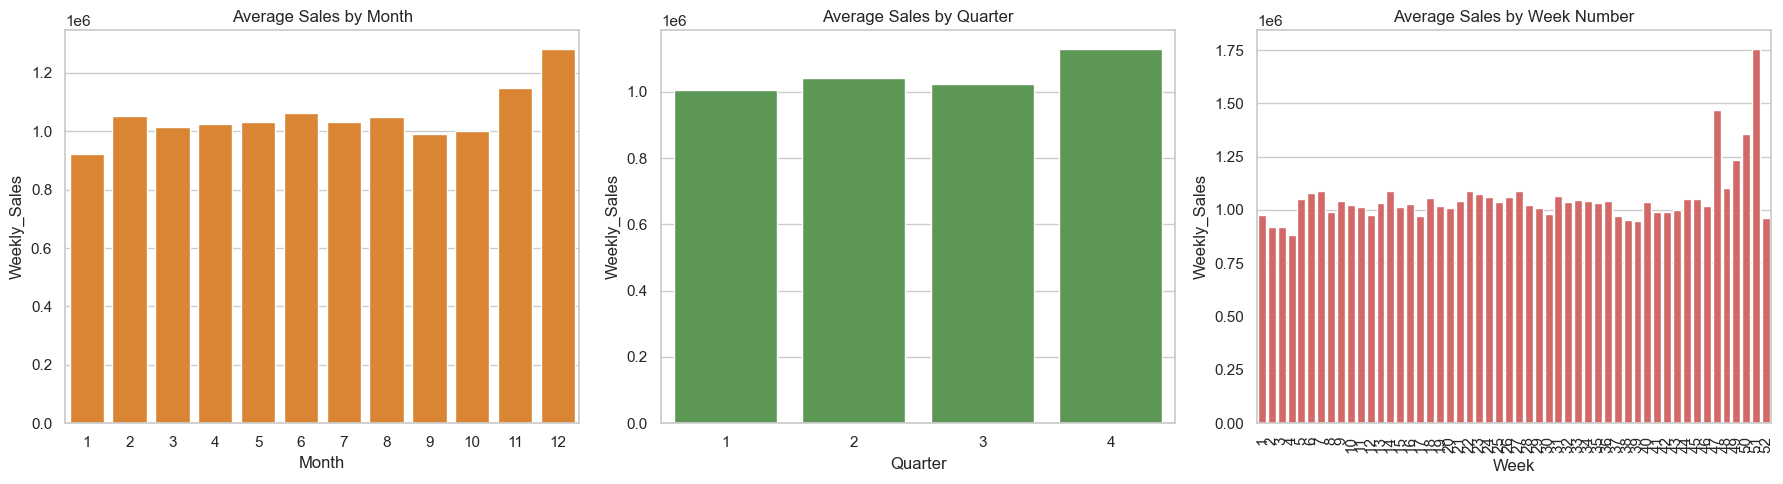

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x="Month", y="Weekly_Sales", estimator=np.mean, errorbar=None, ax=axes[0], color="#f58518")
axes[0].set_title("Average Sales by Month")

sns.barplot(data=df, x="Quarter", y="Weekly_Sales", estimator=np.mean, errorbar=None, ax=axes[1], color="#54a24b")
axes[1].set_title("Average Sales by Quarter")

sns.barplot(data=df, x="Week", y="Weekly_Sales", estimator=np.mean, errorbar=None, ax=axes[2], color="#e45756")
axes[2].set_title("Average Sales by Week Number")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**What this cell outputs:**

This cell plots average sales by month, quarter, and week number. It helps reveal repeating calendar patterns in the data.

**Takeaway:**

Sales are not evenly distributed across the calendar. Some months and quarters perform better than others, which confirms the presence of seasonality and supports keeping `Month`, `Quarter`, and `Week` style features in the modeling pipeline.

## Relationship With External Variables

Correlation Matrix:               Weekly_Sales  Temperature  Fuel_Price   CPI  Unemployment
Weekly_Sales          1.00        -0.06        0.01 -0.07         -0.11
Temperature          -0.06         1.00        0.14  0.18          0.10
Fuel_Price            0.01         0.14        1.00 -0.17         -0.03
CPI                  -0.07         0.18       -0.17  1.00         -0.30
Unemployment         -0.11         0.10       -0.03 -0.30          1.00


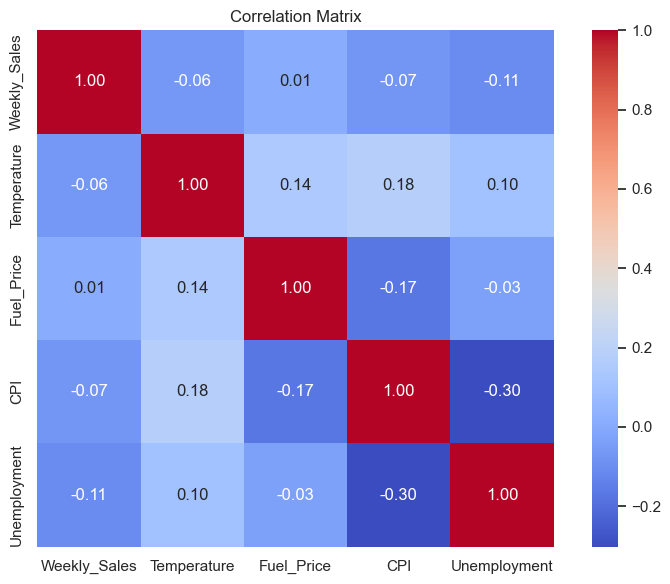

,Weekly_Sales
Weekly_Sales,1.000000
Fuel_Price,0.009464
Temperature,-0.063810
CPI,-0.072634
Unemployment,-0.106176


In [18]:
corr_cols = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"]
corr_matrix = df[corr_cols].corr(numeric_only=True)
print("Correlation Matrix:",corr_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

corr_matrix[["Weekly_Sales"]].sort_values("Weekly_Sales", ascending=False)

**What this cell outputs:**

This cell creates a correlation heatmap and a sorted correlation table focused on `Weekly_Sales`. It measures the linear relationship between sales and the external numeric variables.

**Takeaway:**

The external variables have relatively weak linear relationships with sales compared with the stronger structure we saw in store and calendar behavior. These variables can still be useful, but they probably will not explain sales on their own.

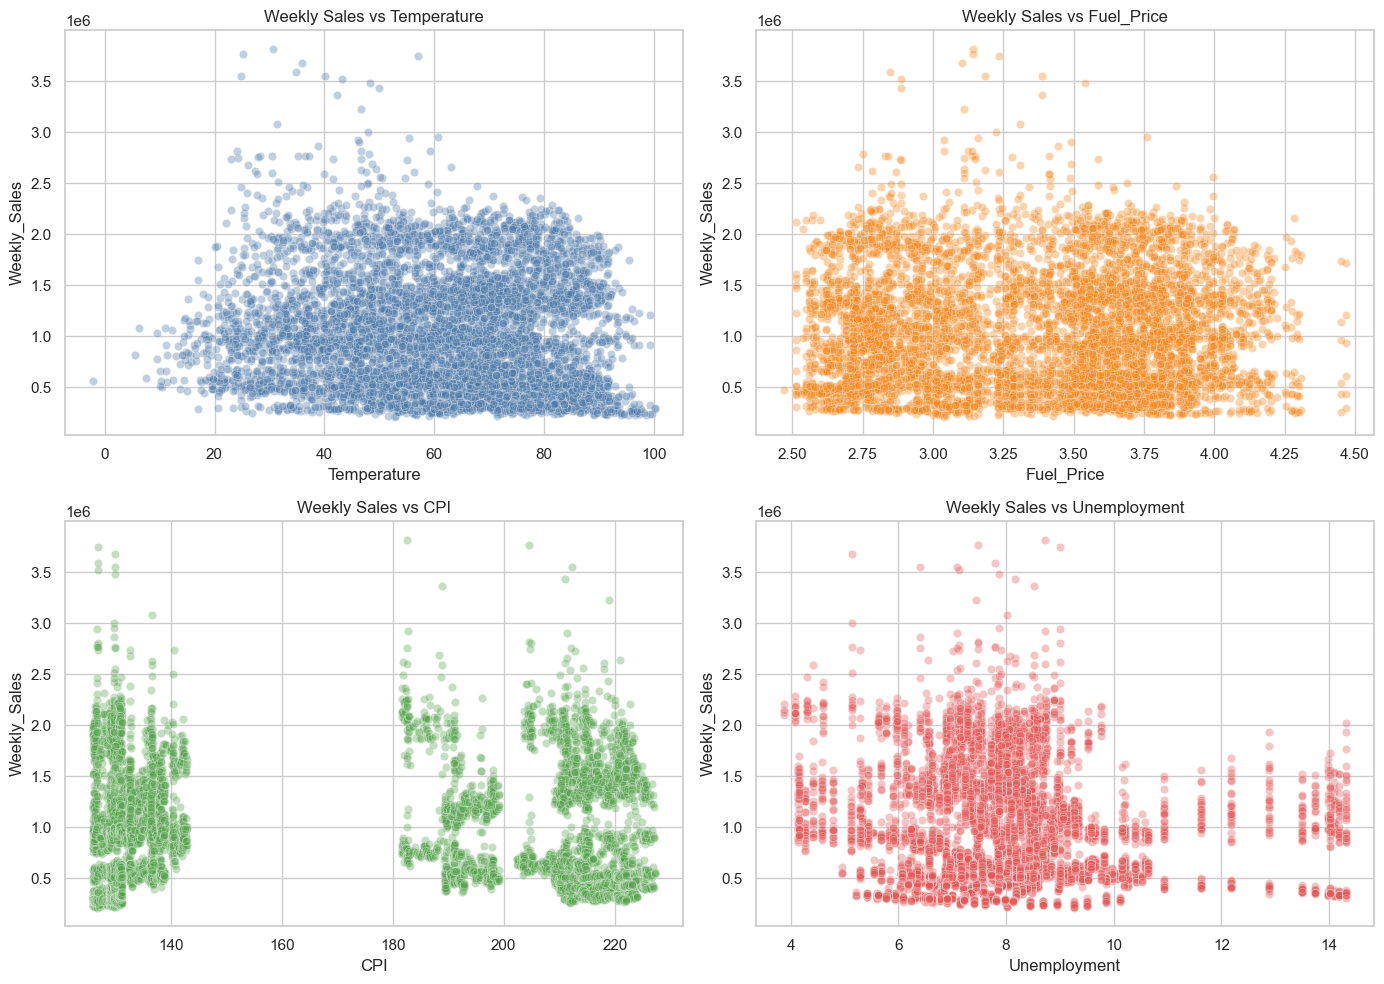

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
feature_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
colors = ["#4c78a8", "#f58518", "#54a24b", "#e45756"]

for ax, col, color in zip(axes.flatten(), feature_cols, colors):
    sns.scatterplot(data=df, x=col, y="Weekly_Sales", alpha=0.35, ax=ax, color=color)
    ax.set_title(f"Weekly Sales vs {col}")

plt.tight_layout()
plt.show()

**What this cell outputs:**

This cell produces scatterplots of `Weekly_Sales` against `Temperature`, `Fuel_Price`, `CPI`, and `Unemployment`. It visually checks whether the relationship looks strong, weak, linear, or noisy.

**Takeaway:**

The point clouds are fairly dispersed, which reinforces the idea that these variables do not have a strong simple relationship with sales. Their value may come more from combining them with time and store information rather than using them alone.

## Summary for Modeling

In [15]:
summary_points = {
    "date_range": f"{df['Date'].min().date()} to {df['Date'].max().date()}",
    "stores": int(df['Store'].nunique()),
    "holiday_weeks": int((df['Holiday_Flag'] == 1).sum()),
    "avg_weekly_sales": round(df['Weekly_Sales'].mean(), 2),
    "top_store_by_avg_sales": int(store_performance.index[0]),
    "best_quarter_by_avg_sales": int(df.groupby('Quarter')['Weekly_Sales'].mean().idxmax()),
    "strongest_non_target_correlation_with_sales": corr_matrix['Weekly_Sales'].drop('Weekly_Sales').abs().idxmax()
}

pd.Series(summary_points, name="EDA Summary")

date_range                                     2010-02-05 to 2012-10-26
stores                                                               45
holiday_weeks                                                       450
avg_weekly_sales                                             1046964.88
top_store_by_avg_sales                                               20
best_quarter_by_avg_sales                                             4
strongest_non_target_correlation_with_sales                Unemployment
Name: EDA Summary, dtype: object

**What this cell outputs:**

This cell presents a compact summary of the most useful EDA facts for modeling, such as date range, number of stores, holiday count, top store, strongest quarter, and strongest non-target correlation.

**Takeaway:**

This summary acts like a quick modeling checklist. It confirms that the forecasting problem is driven mainly by time structure, store differences, and holiday seasonality, with weaker support from the external economic variables.

### Key Takeaways

- The dataset covers weekly store sales from February 2010 to October 2012 across 45 stores.
- Sales vary strongly by store, so store-level modeling or store-aware features will be important.
- Holiday weeks and the fourth quarter tend to show stronger sales patterns.
- External variables have relatively weak linear correlations with sales, so calendar and store features may matter more than raw macro variables alone.
- The time-series trend and recurring weekly or monthly patterns suggest forecasting models should preserve time order and seasonality.